In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [3]:
collection = pd.read_csv('data/Artworks.csv', encoding="utf-8")
collection = collection.dropna(subset=['ConstituentID'])
collection["Medium"] = collection["Medium"].str.strip()
collection["CreditLine"] = collection["CreditLine"].str.strip()
collection['ConstituentID'] = collection['ConstituentID'].str.split(',')
collection = collection.explode('ConstituentID')

collection["DateAcquired"] = pd.to_datetime(collection["DateAcquired"])
collection["YearAcquired"] = collection["DateAcquired"].dt.year

# print(collection["Date"].head(20))
# print(collection["DateAcquired"].head(20))
# print(collection["Gender"].value_counts(dropna=False))
# print(collection["CreditLine"].value_counts().head(20))

In [5]:
def extract_year(val):
    if pd.isna(val):
        return None
    match = re.search(r"\d{4}", str(val))
    return int(match.group()) if match else None

collection["date_made_year"] = collection["Date"].apply(extract_year)
print(collection["date_made_year"].isna().sum())   # how many we couldn't parse
print(collection["date_made_year"].describe())

4550
count    171680.000000
mean       1956.958562
std          34.107483
min        1768.000000
25%        1933.000000
50%        1962.000000
75%        1980.000000
max        3000.000000
Name: date_made_year, dtype: float64


In [6]:
collection["date_made_year"].value_counts()

date_made_year
1971.0    3679
1968.0    3146
1965.0    3077
1966.0    3022
1967.0    3013
          ... 
1811.0       1
1800.0       1
3000.0       1
1822.0       1
1848.0       1
Name: count, Length: 207, dtype: int64

In [7]:
extract_year("c. 1938–60")

1938

In [8]:
collection[collection["date_made_year"]==3000]

,Title,Artist,ConstituentID,ArtistBio,Nationality,BeginDate,EndDate,Gender,Date,Medium,...,Depth (cm),Diameter (cm),Height (cm),Length (cm),Weight (kg),Width (cm),Seat Height (cm),Duration (sec.),YearAcquired,date_made_year
81431,Chopsticks,Unidentified Designer,6011,NaN,(),(0),(0),(),c. 3000 B.C.,Bamboo,...,1.27,NaN,20.955,NaN,NaN,1.27,NaN,NaN,2005.0,3000.0


In [9]:
collection["gender_clean"] = (
    collection["Gender"]
    .str.lower()
    .str.replace(r"[()]", "", regex=True)
    .str.strip()
)

In [10]:
solo_mask = ~collection["gender_clean"].str.contains(" ", na=False)   # no space = single artist
solo = collection[solo_mask]
solo["gender_clean"].value_counts()

gender_clean
male          126701
female         20459
                7796
non-binary        42
Name: count, dtype: int64

In [11]:
collection["has_female"] = collection["gender_clean"].str.contains("female", na=False)
collection.groupby("YearAcquired")["has_female"].mean()  # % of that year's acquisitions with a woman artist

YearAcquired
1929.0    0.000000
1930.0    0.000000
1931.0    0.000000
1932.0    0.052632
1933.0    0.000000
            ...   
2022.0    0.300708
2023.0    0.622283
2024.0    0.289844
2025.0    0.373373
2026.0    0.428811
Name: has_female, Length: 98, dtype: float64

In [12]:
trend = collection.groupby("YearAcquired")["has_female"].mean()
print(trend)

YearAcquired
1929.0    0.000000
1930.0    0.000000
1931.0    0.000000
1932.0    0.052632
1933.0    0.000000
            ...   
2022.0    0.300708
2023.0    0.622283
2024.0    0.289844
2025.0    0.373373
2026.0    0.428811
Name: has_female, Length: 98, dtype: float64


In [13]:
yearly_counts = collection.groupby("YearAcquired").size()
print(yearly_counts.tail(15))

YearAcquired
2012.0    3149
2013.0    4801
2014.0    4599
2015.0    4464
2016.0    2450
2017.0    2028
2018.0    2758
2019.0    2454
2020.0    2811
2021.0    1102
2022.0    1696
2023.0     736
2024.0    1280
2025.0     999
2026.0     597
dtype: int64


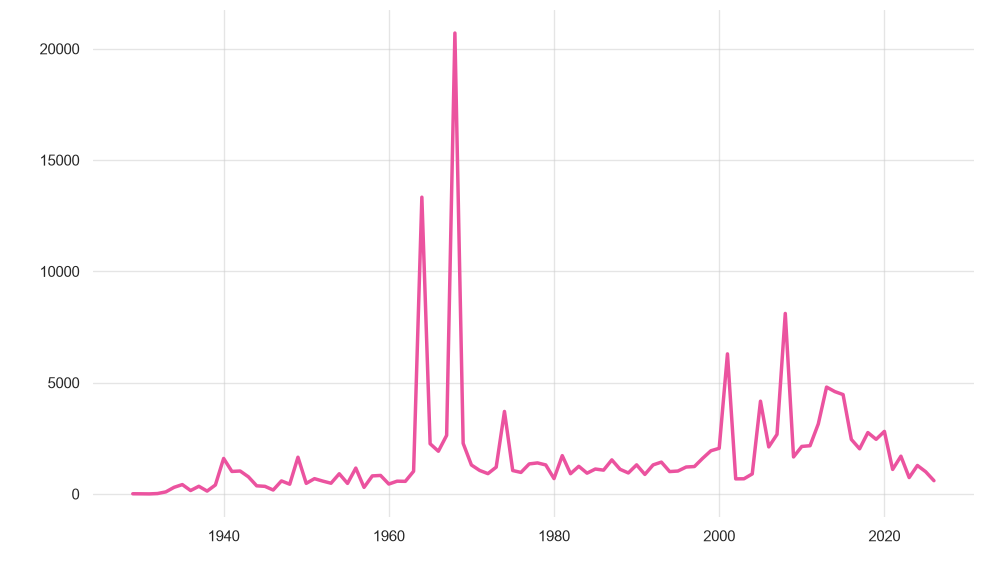

In [51]:
import seaborn as sns
import numpy as np
#
# collection.groupby("YearAcquired").size().plot()
# plt.ylabel("Avg works acquired")
# plt.tight_layout()
# plt.show()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

custom_pink = (235/255, 83/255, 159/255)

# 2. Calculate data and plot with enhanced styling
data = collection.groupby("YearAcquired").size()
# log_data = np.log1p(data)

plt.plot(
    data.index,
    data.values,
    color=custom_pink,      # Deep, sophisticated blue
    linewidth=2.5,        # Slightly thicker line for readability
    # marker='o',           # Add subtle data points
    # markersize=4,
    # markerfacecolor="#57c5b6"
)
# plt.yscale('log')

# 3. Clean up the axes and chart junk
sns.despine(left=True, bottom=True) # Remove the harsh outer box border

# 4. Label with clear typography
# plt.title("Art Collection Acquisition Trend", fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel("Year Acquired", fontsize=12, labelpad=10, color='#FFFFFF')
plt.ylabel("Total Works Acquired", fontsize=12, labelpad=10, color='#FFFFFF') # Corrected from 'Avg'

# 5. Format gridlines to be subtle
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.grid(axis='x', False) # Usually, horizontal lines are enough for time series

plt.savefig(
    "acquisition_chart.png",
    dpi=300,              # High resolution for crisp quality
    transparent=True,     # Makes the background transparent
    bbox_inches='tight'   # Prevents labels from getting cut off
)

plt.tight_layout()
plt.show()

In [14]:
def bucket_credit(text):
    if pd.isna(text):
        return "Unknown"
    t = text.lower()
    if "anonymous" in t:
        return "Anonymous gift"
    if "gift" in t:
        return "Gift"
    if "purchase" in t or "fund" in t or "purchase" in t:
        return "Purchase"
    if "bequest" in t:
        return "Bequest"
    if "transferred" in t:
        return "Transfer"
    if "donation" in t or "courtesy" in t or "acquired" in t or "given" in t or "acquisition" in t:
        return "Donation"
    if "commissioned" in t or "commission" in t:
        return "Commission"
    if "exchange" in t or "Exchange" in t:
        return "Exchange"
    return "Other"

collection["credit_category"] = collection["CreditLine"].apply(bucket_credit)
print(collection["credit_category"].value_counts())

credit_category
Gift              103593
Purchase           43853
Other              15201
Donation            5726
Anonymous gift      3597
Bequest             1751
Unknown             1380
Transfer            1068
Exchange              56
Commission             5
Name: count, dtype: int64


In [15]:
collection[["CreditLine", "credit_category"]].sample(30)

,CreditLine,credit_category
9528,John B. Turner Fund,Purchase
8523,Purchase,Purchase
89963,"Mies van der Rohe Archive, gift of the architect",Gift
158162,"Mies van der Rohe Archive, gift of the architect",Gift
147889,"Mies van der Rohe Archive, gift of the architect",Gift
55923,Walter Bareiss Fund,Purchase
128238,Gift of Patricia Phelps de Cisneros through th...,Gift
84905,The Judith Rothschild Foundation Contemporary ...,Gift
18022,Gift of Emily Fisher Landau,Gift
69381,Gift of Philip Sills,Gift


In [16]:
collection["Nationality"] = collection["Nationality"].str.lower().str.replace(r"[()]", "", regex=True).str.strip()
top_nats = collection["Nationality"].value_counts().head(15)
print(top_nats)

# collection["is_american"] = collection["Nationality"] == "american"
collection["is_american"] = collection["Nationality"].str.contains("american", na=False)
print(collection.groupby("YearAcquired")["is_american"].mean())

Nationality
american                     76244
french                       23076
german                        9875
british                       5931
                              5801
american american             3541
spanish                       3409
italian                       3068
japanese                      2710
russian                       2284
swiss                         2216
dutch                         1713
mexican                       1651
belgian                       1491
hungarian french american     1143
Name: count, dtype: int64
YearAcquired
1929.0    0.333333
1930.0    0.285714
1931.0    0.333333
1932.0    0.157895
1933.0    0.989247
            ...   
2022.0    0.374410
2023.0    0.395380
2024.0    0.705469
2025.0    0.301301
2026.0    0.472362
Name: is_american, Length: 98, dtype: float64


In [17]:
trend_nat = collection.groupby("YearAcquired")["is_american"].mean()
print(trend_nat)

YearAcquired
1929.0    0.333333
1930.0    0.285714
1931.0    0.333333
1932.0    0.157895
1933.0    0.989247
            ...   
2022.0    0.374410
2023.0    0.395380
2024.0    0.705469
2025.0    0.301301
2026.0    0.472362
Name: is_american, Length: 98, dtype: float64


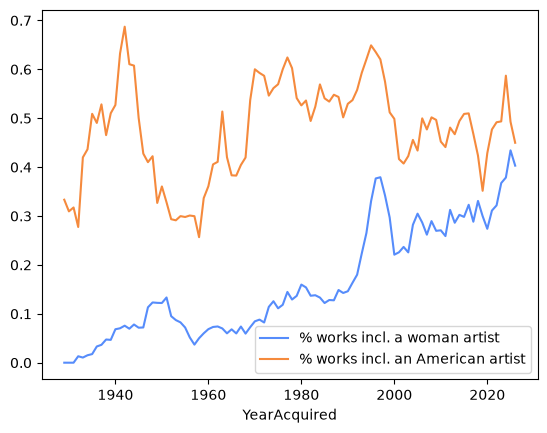

In [18]:
fig, ax = plt.subplots()
trend.rolling(5, min_periods=1).mean().plot(ax=ax, label="% works incl. a woman artist")
trend_nat.rolling(5, min_periods=1).mean().plot(ax=ax, label="% works incl. an American artist")
ax.legend()
plt.show()

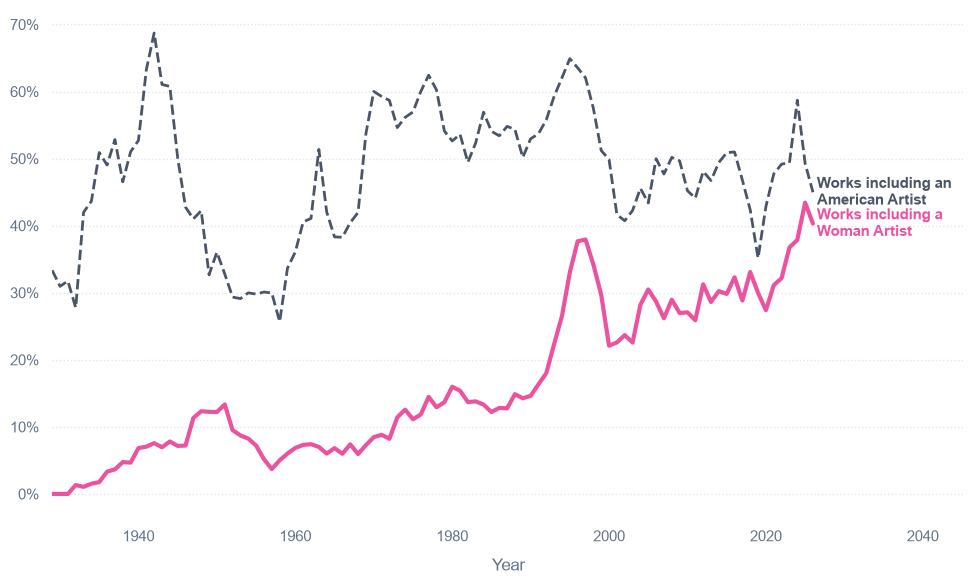

In [53]:
import matplotlib.ticker as mtick
import seaborn as sns

# 1. Define a sleek color palette
# Using your signature pink for the primary metric, and a slate blue for the comparison
color_woman = (235/255, 83/255, 159/255)       # Pink rgb(235, 83, 159)
color_american = (74/255, 85/255, 104/255)     # Slate Blue/Gray

# 2. Initialize plot
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Calculate 5-year rolling means
data_woman = trend.rolling(5, min_periods=1).mean()
data_american = trend_nat.rolling(5, min_periods=1).mean()

# 4. Plot the lines with polished styling
ax.plot(data_woman.index, data_woman.values, color=color_woman, linewidth=3, label="Woman Artist")
ax.plot(data_american.index, data_american.values, color=color_american, linewidth=2, linestyle='--', label="American Artist")

# 5. Clean up gridlines and borders (Data-to-Ink ratio)
sns.despine(left=True, bottom=True)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#cbd5e1') # Subtle dotted grid

# 6. Format Y-axis as actual percentages (e.g., "20%" instead of "20" or "0.2")
# Note: If your raw data is 0.20 for 20%, use PercentFormatter(1.0). If it's 20 for 20%, use PercentFormatter(100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0 if data_woman.max() <= 1.0 else 100))
ax.tick_params(colors='#64748b', labelsize=11) # Muted gray axis labels

# 7. Typography: Strong title hierarchy
# plt.title("Representation Trends in Art Acquisitions", fontsize=18, fontweight='bold', pad=25, color='#1e293b', loc='left')
plt.xlabel("Year", fontsize=12, labelpad=10, color='#64748b')

# 8. Modern Alternative to Legends: Direct Inline Labels
# We find the last year in the index to place text right next to the end of the lines
last_year = data_woman.index[-1]
last_val_woman = data_woman.values[-1]
last_val_american = data_american.values[-1]

ax.text(last_year + 0.5, last_val_woman, 'Works including a\nWoman Artist',
        color=color_woman, fontweight='bold', va='center', fontsize=11)
ax.text(last_year + 0.5, last_val_american, 'Works including an\nAmerican Artist',
        color=color_american, fontweight='bold', va='center', fontsize=11)

# Extend the x-axis limits slightly so the labels aren't cut off
ax.set_xlim(data_woman.index.min(), last_year + (last_year - data_woman.index.min()) * 0.2)

# 9. Handle transparency & save
ax.set_facecolor('none')
fig.patch.set_alpha(0.0)

plt.tight_layout()
plt.savefig("representation_trends.png", dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [19]:
top_donors = collection["CreditLine"].value_counts().head(5)
print(top_donors)

CreditLine
Mies van der Rohe Archive, gift of the architect         16324
The Louis E. Stern Collection                            11632
Gift of the artist                                       10854
Purchase                                                  8659
The Gilbert and Lila Silverman Fluxus Collection Gift     5723
Name: count, dtype: int64


In [20]:
top3_names = collection["CreditLine"].value_counts().head(3).index.tolist()
print(top3_names)   # confirm which ones you're excluding

filtered = collection[~collection["CreditLine"].isin(top3_names)]

trend_gender_filtered = filtered.groupby("YearAcquired")["has_female"].mean()
trend_gender_full = collection.groupby("YearAcquired")["has_female"].mean()

['Mies van der Rohe Archive, gift of the architect', 'The Louis E. Stern Collection', 'Gift of the artist']


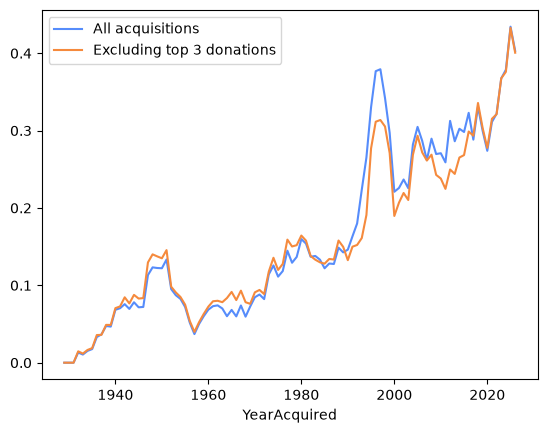

In [21]:
fig, ax = plt.subplots()
trend_gender_full.rolling(5, min_periods=1).mean().plot(ax=ax, label="All acquisitions")
trend_gender_filtered.rolling(5, min_periods=1).mean().plot(ax=ax, label="Excluding top 3 donations")
ax.legend()
plt.show()

In [22]:
collection.groupby("YearAcquired")["Artist"].count()

YearAcquired
1929.0       9
1930.0       7
1931.0       3
1932.0      19
1933.0      93
          ... 
2022.0    1696
2023.0     736
2024.0    1280
2025.0     999
2026.0     597
Name: Artist, Length: 98, dtype: int64

In [23]:
collection["YearAcquired"].nunique()

98

In [24]:
print(collection.groupby("YearAcquired")["Artist"].nunique().describe())

count      98.000000
mean      294.704082
std       186.337473
min         3.000000
25%       189.000000
50%       275.000000
75%       351.500000
max      1014.000000
Name: Artist, dtype: float64


In [25]:
collection["ImageURL"].isna().mean()

np.float64(0.40149804233104464)

In [26]:
year_stats = collection.groupby("YearAcquired").agg(
    pct_women=("has_female", "mean"),
    pct_american=("is_american", "mean")
).reset_index()

print(year_stats.head())

   YearAcquired  pct_women  pct_american
0        1929.0   0.000000      0.333333
1        1930.0   0.000000      0.285714
2        1931.0   0.000000      0.333333
3        1932.0   0.052632      0.157895
4        1933.0   0.000000      0.989247


In [27]:
def sample_year(year_df, n=40):
    n_sample = min(n, len(year_df))
    sampled = year_df.sample(n=n_sample, random_state=42)
    # return sampled[["Title", "Artist", "ImageURL", "gender_clean", "Nationality"]].to_dict(orient="records")

    columns = ["Title", "Artist", "ImageURL", "gender_clean", "Nationality"]

    return sampled[columns].replace({float('nan'): None}).to_dict(orient="records")


In [28]:
test_year = collection[collection["YearAcquired"] == 2000]
sample = sample_year(test_year)
print(len(sample))
# print(sample[3])   # inspect one record's shape
sample[3]

40


{'Title': 'Bottle pumpkin from perfect world (for Parkett no. 58)',
 'Artist': 'Jason Rhoades',
 'ImageURL': None,
 'gender_clean': 'male',
 'Nationality': 'american'}

In [29]:
multi_artist_sample = collection[collection["gender_clean"].str.contains(" ", na=False)].sample(3, random_state=1)
print(multi_artist_sample[["Title", "Artist", "gender_clean", "Nationality"]])

                              Title  \
142687       "Transglass" Glassware   
139432  Huntington Beach (Skeleton)   
123115             Swissair - Japan   

                                           Artist    gender_clean  \
142687               Tord Boontje, Emma Woffenden       male male   
139432             Ed Templeton, Deanna Templeton     male female   
123115  Emil Schulthess, Georg Gerster, Hans Frei  male male male   

              Nationality  
142687      dutch british  
139432  american american  
123115  swiss swiss swiss  


In [30]:
import json

years_data = []

for year, group in collection.groupby("YearAcquired"):
    if pd.isna(year):
        continue
    stats = year_stats[year_stats["YearAcquired"] == year].iloc[0]
    years_data.append({
        "year": int(year),
        "pct_women": round(stats["pct_women"], 4),
        "pct_american": round(stats["pct_american"], 4),
        "sample_artists": sample_year(group)
    })

output = {"years": years_data}

with open("moma_constellations.json", "w") as f:
    json.dump(output, f, indent=2)

print(len(years_data))

98


In [71]:
# def tmp_edium(text):
#     t = text.lower()
#     # print(text)
#     if pd.isna(text):
#         return
#     elif "software" in text:
#         print(text)
#
# collection["Medium"].apply(tmp_edium)

In [65]:
collection[["Medium"]].value_counts()

Medium                                                                                                                                              
Gelatin silver print                                                                                                                                    19195
Lithograph                                                                                                                                               9860
Pencil on paper                                                                                                                                          7352
Albumen silver print                                                                                                                                     4950
Pencil on tracing paper                                                                                                                                  3297
                                                             